## Activity plots of elements and regions
- activity of tested vs controls
- activity difference of different groups of regions
    - based on gene_list
    - open in NGN2 derived neurons
    - open in neural progenitors from screen 
    - open in undifferenciated WTC11 

In [1]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [2]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

write_output = False

# helpful functions
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


def add_mk_shuffled_label(row, name_col="name", label_col="label"):
    """Add a scrambled MK label because only these sequences are good to compare against"""
    # MK:tile_21585|chr2-59828493+59828762|scramble_negative => scrambled
    name = row[name_col]
    row[label_col] = hf.get_label(name)
    if name.startswith('MK'):
        if "scramble" in name:
            row[label_col] = "negative_scrambled"
    return row

# def rename_tested_label(row, name_col="name", label_col="label", previous_name="cardiac_neuro_cava_random", name_of_tested="tested_sequences"):
#     """Rename the tested label to name of tested"""
#     name = row[name_col]
#     if name.startswith(previous_name):
#         row[label_col] = name_of_tested
#     return row


neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK']
neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK']
neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK']
positive_controls = [control for control in neuro_controls if 'positive' in control.lower()]
negative_controls = [control for control in neuro_controls if 'negative' in control.lower()]

def is_pos_control(label):
    """returns if positive control"""
    return 'yes' if label in positive_controls else 'no'

def is_neg_control(label):
    """returns if positive control"""
    return 'yes' if label in negative_controls else 'no'

def is_tested_sequence(label):
    """returns if tested sequence"""
    return 'yes' if label == 'cardiac_neuro_cava_random' else 'no'

def plotting_control_tested_column(row):
    if row['is_positive_control'] == 'yes':
        return 'positive control'
    elif row['is_negative_control'] == 'yes':
        return 'negative control'
    elif row['is_tested_sequence'] == 'yes':
        return 'tested sequences'
    else:
        return np.nan

### Controls vs tested regions

In [ ]:
# extract the sequences fast:
input_elements = "element_metadata_with_bcalm_2025_02_bbmap_scrambled"

# use results of bbmap
element_bcalm_metadata_df = pd.read_csv(config['files']['creating'][input_elements], low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    element_bcalm_metadata_df[col] = element_bcalm_metadata_df[col].apply(safe_eval)

# add the negative scrambled label
element_bcalm_metadata_df = element_bcalm_metadata_df.apply(lambda row: add_mk_shuffled_label(row, name_col="name", label_col="label"), axis=1).copy()

In [10]:
element_bcalm_metadata_df['label'].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    1897
C_positive_heart_AB                    909
negative_scrambled                     500
GC_Selvarajan                          358
GC_Vista                               256
C_negative_heart_MK                    243
C_negative_neuron_MK                   222
C_negative_neuron_NP                   217
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_neuron_NP                    99
C_positive_heart_MK                     97
C_positive_neuron_MK                    96
C_positive_neuron_CD                    94
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         42
GC_DNase_positive                       41
GC_Mo

In [11]:
"GC_Hon", "GC_Liang", "GC_Mohlke", "GC_GABA_Chengyu", "GC_Glut_Chengyu", "GC_Kircher", "C_SLEA"

all_neuro_element_controls = ["C_negative_neuron_MK", "C_negative_neuron_NP", "C_positive_neuron_CD", "C_positive_neuron_MK", "C_positive_neuron_NP", "GC_Vista", "negative_scrambled"]
neuro_element_controls_subset = ["C_negative_neuron_MK", "C_positive_neuron_MK", "C_negative_neuron_NP", "C_positive_neuron_NP", "negative_scrambled"]

#### Focus only on the tested group: 


In [12]:
# element_bcalm_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")]
# element_bcalm_metadata_df

In [13]:
element_bcalm_metadata_df_tested_and_neuro_controls = element_bcalm_metadata_df.loc[element_bcalm_metadata_df['label'].isin(["cardiac_neuro_cava_random"] + all_neuro_element_controls)].copy()
element_bcalm_metadata_df_tested_and_neuro_controls_subset = element_bcalm_metadata_df.loc[element_bcalm_metadata_df['label'].isin(["cardiac_neuro_cava_random"] + neuro_element_controls_subset)].copy()

In [14]:
element_bcalm_metadata_df_tested_and_neuro_controls.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label'],
      dtype='object')

In [15]:
element_bcalm_metadata_df_tested_and_neuro_controls.label.value_counts()

label
cardiac_neuro_cava_random    73940
negative_scrambled             500
GC_Vista                       256
C_negative_neuron_MK           222
C_negative_neuron_NP           217
C_positive_neuron_NP            99
C_positive_neuron_MK            96
C_positive_neuron_CD            94
Name: count, dtype: int64

In [16]:
element_bcalm_metadata_df_tested_and_neuro_controls['is_positive_control'] = element_bcalm_metadata_df_tested_and_neuro_controls['label'].apply(is_pos_control)
element_bcalm_metadata_df_tested_and_neuro_controls['is_negative_control'] = element_bcalm_metadata_df_tested_and_neuro_controls['label'].apply(is_neg_control)
element_bcalm_metadata_df_tested_and_neuro_controls['is_tested_sequence'] = element_bcalm_metadata_df_tested_and_neuro_controls['label'].apply(is_tested_sequence)
element_bcalm_metadata_df_tested_and_neuro_controls['plotting_label'] = element_bcalm_metadata_df_tested_and_neuro_controls.apply(plotting_control_tested_column, axis=1)
element_bcalm_metadata_df_tested_and_neuro_controls.head()
element_bcalm_metadata_df_tested_and_neuro_controls['is_positive_control'].value_counts()
element_bcalm_metadata_df_tested_and_neuro_controls['is_negative_control'].value_counts()

is_negative_control
no     74985
yes      439
Name: count, dtype: int64

In [17]:
element_bcalm_metadata_df_tested_and_neuro_controls_subset['is_positive_control'] = element_bcalm_metadata_df_tested_and_neuro_controls_subset['label'].apply(is_pos_control)
element_bcalm_metadata_df_tested_and_neuro_controls_subset['is_negative_control'] = element_bcalm_metadata_df_tested_and_neuro_controls_subset['label'].apply(is_neg_control)
element_bcalm_metadata_df_tested_and_neuro_controls_subset['is_tested_sequence'] = element_bcalm_metadata_df_tested_and_neuro_controls_subset['label'].apply(is_tested_sequence)
element_bcalm_metadata_df_tested_and_neuro_controls_subset['plotting_label'] = element_bcalm_metadata_df_tested_and_neuro_controls_subset.apply(plotting_control_tested_column, axis=1)
element_bcalm_metadata_df_tested_and_neuro_controls_subset.head()
element_bcalm_metadata_df_tested_and_neuro_controls_subset['is_positive_control'].value_counts()
element_bcalm_metadata_df_tested_and_neuro_controls_subset['is_negative_control'].value_counts()

is_negative_control
no     74635
yes      439
Name: count, dtype: int64

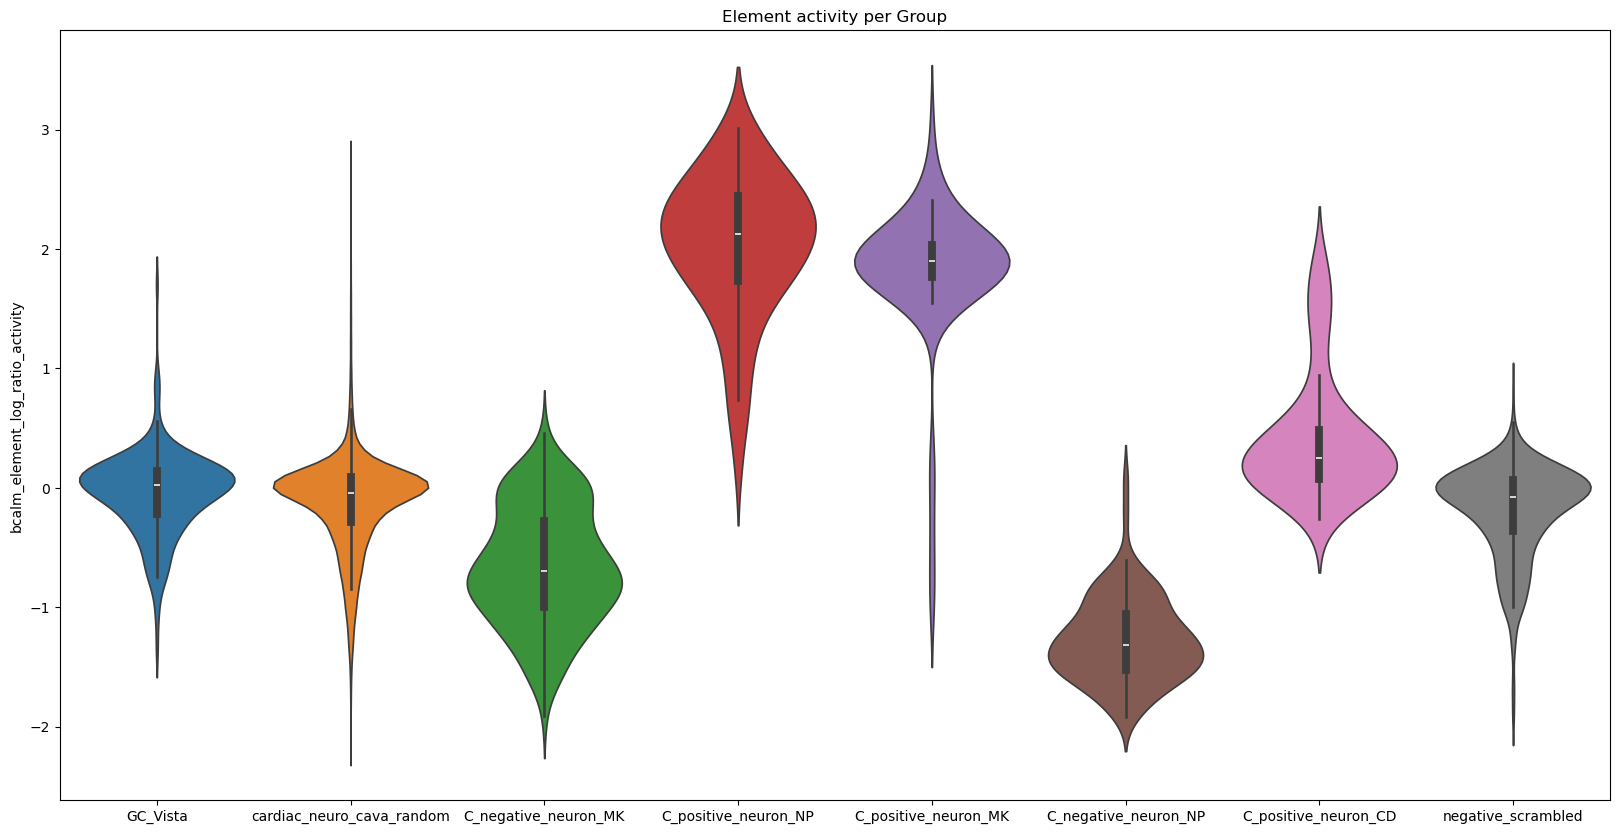

In [18]:
# plot a violine boxplot split by label colored and with a colored label and add the number of barcodes per label
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
# ax = sns.violinplot(x="label", y="barcodes", hue="label", data=bwa_association_filtered_counts_label)
ax = sns.violinplot(x="label", y="bcalm_element_log_ratio_activity", hue="label", data=element_bcalm_metadata_df_tested_and_neuro_controls)
plt.title(f"Element activity per Group")

# remove x label
plt.xlabel('')
plt.show()

# # add the number of barcodes per label
# for i in range(element_bcalm_metadata_df_tested_and_neuro_controls.shape[0]):
#     plt.text(i, ax.get_ylim()[1]-35, f"group size:\n{element_bcalm_metadata_df_tested_and_neuro_controls['name']['nunique'][i]}", ha='center', va='bottom')
#     plt.text(i, ax.get_ylim()[0], f"median: {round(element_bcalm_metadata_df_tested_and_neuro_controls['barcodes']['median'][i])}", ha='center', va='bottom')
#     # plt.text(i, ax.get_ylim()[0], f"median: {round(element_bcalm_metadata_df_tested_and_neuro_controls['barcodes']['median'][i])} (mean: {round(label_barcode_counts['barcodes']['mean'][i], 2)})", ha='center', va='bottom')
#     # plt.text(i, ax.get_ylim()[0], f"mean: {round(label_barcode_counts['n_assigned_barcodes']['mean'][i], 2)}", ha='center', va='bottom')




# # save the figure
# plt.savefig(config['results']['plots']['assignement_barcodes_violin_plot_grouped_by_label'])


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.ti

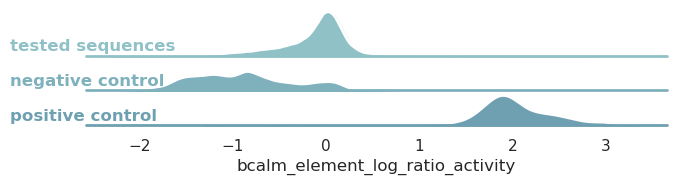

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# # Create the data
# rs = np.random.RandomState(1979)
# x = rs.randn(500)
# g = np.tile(list("ABCDEFGHIJ"), 50)
# df = pd.DataFrame(dict(x=x, g=g))
# m = df.g.map(ord)
# df["x"] += m
element_bcalm_metadata_df_tested_and_neuro_controls_subset


# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(element_bcalm_metadata_df_tested_and_neuro_controls_subset, row="plotting_label", hue="plotting_label", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.13, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "bcalm_element_log_ratio_activity")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# save figure
# plt.savefig(os.path.join(plot_directory, f'controls_vs_tested_sequences.png'), dpi=300, bbox_inches='tight')

In [20]:
element_bcalm_metadata_df_tested_and_neuro_controls_subset['plotting_label'].value_counts()
# element_bcalm_metadata_df_tested_and_neuro_controls_subset.loc[element_bcalm_metadata_df_tested_and_neuro_controls_subset['plotting_label'] == "negative control"]['label'].value_counts()

plotting_label
tested sequences    73940
negative control      439
positive control      195
Name: count, dtype: int64

In [21]:
element_bcalm_metadata_df_tested = element_bcalm_metadata_df.loc[element_bcalm_metadata_df['label'].isin(["cardiac_neuro_cava_random"])].copy()
element_bcalm_metadata_df_tested[col_start] = element_bcalm_metadata_df_tested[col_start].astype(int)
element_bcalm_metadata_df_tested[col_end] = element_bcalm_metadata_df_tested[col_end].astype(int)

In [22]:
# add the element p-value for comparison against negative control
# number of active elements compared to negative neuro
# /home/kisa/coding/80K_MPRA/element_analysis_output/202501_80k_element_bbmap_outlier_removed_toptreat_results.tsv
# element_bcalm_metadata_df_tested_elements_bcalm.columns
element_negative_neuron_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202501_80k_element_bbmap_outlier_removed_toptreat_results.tsv"
element_bcalm_metadata_df_tested_elements_bcalm_negative_neuron = pd.read_csv(element_negative_neuron_path, sep="\t")
element_bcalm_metadata_df_tested_elements_bcalm_negative_neuron

,logFC,AveExpr,t,P.Value,adj.P.Val,name
0,2.553902,2.553977,74.674806,3.198883e-286,2.272486e-281,MK:newcore_12125|chr1-52662897+52663166|refere...
1,2.560693,2.560953,74.150747,1.008186e-284,3.581075e-280,MK:newcore_12125|chr1-52662897+52663166|refere...
2,2.406847,2.406870,74.002845,2.679418e-284,6.344862e-280,MK:tile_37639|chr6-112501812+112502081|reference
3,2.533447,2.533640,73.409443,1.374764e-282,2.441581e-278,MK:newcore_12125|chr1-52662897+52663166|reference
4,2.389269,2.389367,72.605480,2.974418e-280,4.226053e-276,C_positive_neuron_MK:tile_37639_chr6_112501812...
...,...,...,...,...,...,...
71035,-1.286619,-1.286715,0.000000,1.000840e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_SLX4|ENSG0000018...
71036,-1.264096,-1.264328,0.000000,1.000874e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_CPS1|ENSG0000002...
71037,-1.272377,-1.272286,0.000000,1.001053e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_ANK2|ENSG0000014...
71038,-1.276488,-1.276636,0.000000,1.001234e+00,1.000000e+00,cardiac_neuro_cava_random:ALT_TRIP12|ENSG00000...


In [23]:
element_bcalm_metadata_df_tested_elements_bcalm_negative_neuron.rename(columns={"adj.P.Val": "element_vs_negative_control_adj_pValue", "logFC": "element_vs_negative_control_activity_logFC"}, inplace=True)

In [24]:
element_bcalm_metadata_df_tested_elements_bcalm_negative_neuron.columns


Index(['element_vs_negative_control_activity_logFC', 'AveExpr', 't', 'P.Value',
       'element_vs_negative_control_adj_pValue', 'name'],
      dtype='object')

In [25]:
element_bcalm_metadata_df_tested = element_bcalm_metadata_df_tested.merge(element_bcalm_metadata_df_tested_elements_bcalm_negative_neuron[['element_vs_negative_control_activity_logFC', 'element_vs_negative_control_adj_pValue', 'name']], on=col_name, how="left")

In [26]:
# if a & b == only A than b is at least all the times true as A is
(element_bcalm_metadata_df_tested["bcalm_data_exists"] & element_bcalm_metadata_df_tested["element_vs_negative_control_adj_pValue"]).sum()
 # 64042
element_bcalm_metadata_df_tested["bcalm_data_exists"].sum() # 64042 => expected

64042

In [27]:
element_bcalm_metadata_df_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,...,variant_pos,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,element_vs_negative_control_activity_logFC,element_vs_negative_control_adj_pValue
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,None,None,None,NaN,0.151004,-0.924899,True,cardiac_neuro_cava_random,-0.922803,1.000000e+00
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,None,None,None,NaN,1.000000,0.233557,True,cardiac_neuro_cava_random,0.233262,6.968128e-11
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,None,None,None,NaN,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,None,None,None,NaN,NaN,NaN,False,cardiac_neuro_cava_random,NaN,NaN
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,None,None,None,NaN,1.000000,-0.203536,True,cardiac_neuro_cava_random,-0.204602,1.400712e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,[64],[NC_000023.11:154545205:A:G],[alt],NaN,0.125401,0.606762,True,cardiac_neuro_cava_random,0.606568,5.263641e-12
73936,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,[149],[NC_000023.11:154549922:T:G],[alt],NaN,0.000484,-1.170305,True,cardiac_neuro_cava_random,-1.170657,1.000000e+00
73937,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[126],[NC_000023.11:154552288:C:T],[alt],NaN,0.821584,0.344769,True,cardiac_neuro_cava_random,0.344616,4.016178e-22
73938,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[44],[NC_000023.11:154552370:G:A],[alt],NaN,1.000000,0.018269,True,cardiac_neuro_cava_random,0.018090,2.110636e-05


### Open chromatin regions:
- add is open in columns

In [28]:
# write all distinct regions to file for intersecting with the open chromatin information

In [29]:
element_bcalm_metadata_df_tested_elements = element_bcalm_metadata_df_tested.loc[~element_bcalm_metadata_df_tested[col_name].str.contains(":ALT_")].copy()
print("Number of different regions: ", element_bcalm_metadata_df_tested_elements.shape[0])
print("Number of different regions: ", element_bcalm_metadata_df_tested_elements[col_name].nunique())
print("Number of diplicated regions considering the strand: ", element_bcalm_metadata_df_tested_elements.duplicated(subset=[col_chr, col_start, col_end, col_strand]).sum())
print("Number of diplicated regions considering the strand: ", element_bcalm_metadata_df_tested_elements.duplicated(subset=[col_chr, col_start, col_end]).sum()) # 273 same region different strand

print("Number of different regions in the design: ", element_bcalm_metadata_df_tested_elements.drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0])

sig_level = 0.05
print("Number of different regions in the design after bcalm: ", element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements["bcalm_data_exists"]].drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0])

more_active_scrambled_ctrl = element_bcalm_metadata_df_tested_elements.loc[(element_bcalm_metadata_df_tested_elements["bcalm_element_log_ratio_activity"] > 0) & (element_bcalm_metadata_df_tested_elements["bcalm_element_adjusted_p_value"]<sig_level)].copy()
more_active_negative_ctrl = element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements["element_vs_negative_control_adj_pValue"]<sig_level].copy()
print("Number of different regions significantly more active than scrambled: ", more_active_scrambled_ctrl.drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0])
print("Number of different regions significantly more active than negative control: ", more_active_negative_ctrl.drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0])

Number of different regions:  27482
Number of different regions:  27482
Number of diplicated regions considering the strand:  0
Number of diplicated regions considering the strand:  273
Number of different regions in the design:  27209
Number of different regions in the design after bcalm:  24082
Number of different regions significantly more active than scrambled:  546
Number of different regions significantly more active than negative control:  20011


In [ ]:
# proportions for presentation:
# proportion of active compared to negative control
print(f"Ratio of elements which are tested and we have measurements for: {element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements['bcalm_data_exists']].drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0]} {round(element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements['bcalm_data_exists']].drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0]/element_bcalm_metadata_df_tested_elements.drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0]*100,2)}%")
print(f"Ratio of elements which are tested and active compared to the negative control: {more_active_negative_ctrl.shape[0]} {round(more_active_negative_ctrl.shape[0]/element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements['bcalm_data_exists']].drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0]*100,2)}%")
print(f"Ratio of elements which are tested and active compared to the scrambled control: {more_active_scrambled_ctrl.shape[0]} {round(more_active_scrambled_ctrl.shape[0]/element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements['bcalm_data_exists']].drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0]*100,2)}%")

Ratio of elements which are tested and we have measurements for: 24082 88.51%
Ratio of elements which are tested and active compared to the negative control: 20113 83.52%
Ratio of elements which are tested and active compared to the negative control: 547 2.27%


In [31]:
def get_region_id(row, chr_col="chr", start_col="start", end_col="end"):
    return f'{row[chr_col]}:{row[start_col]}-{row[end_col]}'
element_bcalm_metadata_df_tested_elements['region_id'] = element_bcalm_metadata_df_tested_elements.apply(lambda row: get_region_id(row, chr_col=col_chr, start_col=col_start, end_col=col_end), axis=1)

In [32]:
open_chrom_output_dir = config['files']['creating']['open_chromatin_2025_output_dir']
output_path_80k_regions = os.path.join(open_chrom_output_dir, "all_80k_regions.bed")
if write_output:
    element_bcalm_metadata_df_tested_elements[[col_chr, col_start, col_end, 'region_id']].to_csv(output_path_80k_regions, sep="\t", header=None, index=False)

In [33]:
output_path_80k_regions

'/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed'

#### Bedtools intersect with different open-chromatin datasets: 
- screen neural progenitor: 
- prpare data: `zcat /home/kisa/coding/80K_MPRA/cCRE_ENCODE_neural_progenitor/ENCFF221LCO_neural_progenitor_cCRE_raw.bed.gz | grep -v "Low-DNase" | grep -vE "\bCA\-" | grep -v "CTCF" | gzip > /home/kisa/coding/80K_MPRA/cCRE_ENCODE_neural_progenitor/ENCFF221LCO_neural_progenitor_cCRE_open_filtered.bed.gz`
    - bedtools intersect -f 0.33 -F 0.33 -e -a /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed -b /home/kisa/coding/80K_MPRA/cCRE_ENCODE_neural_progenitor/ENCFF221LCO_neural_progenitor_cCRE_open_filtered.bed.gz -wa > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_SCREEN_ENCFF221LCO_neural_progenitor_033.bed

    - bedtools intersect -f 0.5 -F 0.5 -e -a /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed -b /home/kisa/coding/80K_MPRA/cCRE_ENCODE_neural_progenitor/ENCFF221LCO_neural_progenitor_cCRE_open_filtered.bed.gz -wa > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_SCREEN_ENCFF221LCO_neural_progenitor_05.bed

- wtc11 ngn2 overlap: 
    - bedtools intersect -f 0.5 -F 0.5 -e -a /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/wtc11_ngn2_atac_peak.bed -wa > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_05.bed 
    - bedtools intersect -f 0.33 -F 0.33 -e -a /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed -b /home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/wtc11_ngn2_atac_peak.bed -wa > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_033.bed 

- screen neural progenitor h9 overlap
  - filtering of cCRE file: cat /home/kisa/coding/80K_MPRA/2025_IGVF_design_WTC11_neural_progenitors/resources/cCREs_neural_progenitor_H9_SCREEN/ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed | grep -v "Low-DNase" | grep -vE "\bCA\-" | grep -v "CTCF" > /home/kisa/coding/80K_MPRA/2025_IGVF_design_WTC11_neural_progenitors/resources/cCREs_neural_progenitor_H9_SCREEN/ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP_neural_progenitor_H9_filtered.bed


In [34]:
open_prefix = "screen_ENCFF221LCO_neural_progenitor"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_SCREEN_ENCFF221LCO_neural_progenitor_033.bed"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_SCREEN_ENCFF221LCO_neural_progenitor_05.bed"
open_in_screen_neural_progenitor = pd.read_csv(open_input_data, sep="\t", names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'])

In [35]:
open_in_screen_neural_progenitor_id_list = open_in_screen_neural_progenitor[f'tmp_open_{open_prefix}_id'].to_list()
element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'] = element_bcalm_metadata_df_tested_elements['region_id'].isin(open_in_screen_neural_progenitor_id_list)

In [36]:
print("Number of open regions: ", element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'].sum())

Number of open regions:  1481


In [37]:
element_bcalm_metadata_df_tested_elements[f'open_screen_ENCFF221LCO_neural_progenitor'].value_counts()

open_screen_ENCFF221LCO_neural_progenitor
False    26001
True      1481
Name: count, dtype: int64

In [38]:
tmp_columns = [col for col in element_bcalm_metadata_df_tested_elements.columns if "tmp_" in col]
element_bcalm_metadata_df_tested_elements.drop(columns=tmp_columns, inplace=True)

In [39]:
element_bcalm_metadata_df_tested_elements.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor'],
      dtype='object')

In [40]:
open_prefix = "NGN2_wtc11_atac"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_033.bed"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_05.bed"
open_in_progenitor = pd.read_csv(open_input_data, sep="\t", names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'])

print("Number of open regions: ", open_in_progenitor[f'tmp_open_{open_prefix}_id'].nunique())

open_in_id_list = open_in_progenitor[f'tmp_open_{open_prefix}_id'].to_list()
element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'] = element_bcalm_metadata_df_tested_elements['region_id'].isin(open_in_id_list)
element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'].value_counts()

Number of open regions:  283


open_NGN2_wtc11_atac
False    27196
True       286
Name: count, dtype: int64

In [41]:
element_bcalm_metadata_df_tested_elements.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac'],
      dtype='object')

In [42]:
def screen_id_in_name(name, screen_id_list):
    for screen_id in screen_id_list:
        if screen_id in name:
            return True
    return False

In [43]:
open_prefix = "H9_neural_progenitor"
open_input_data = "/home/kisa/coding/80K_MPRA/2025_IGVF_design_WTC11_neural_progenitors/resources/cCREs_neural_progenitor_H9_SCREEN/ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP_neural_progenitor_H9_filtered.bed"
open_in_progenitor = pd.read_csv(open_input_data, sep="\t", header=None, names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'] + [num for num in range(11-4)])
open_in_progenitor
print("Number of open regions: ", open_in_progenitor[f'tmp_open_{open_prefix}_id'].nunique())

open_in_id_list = open_in_progenitor[f'tmp_open_{open_prefix}_id'].to_list()

element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'] = element_bcalm_metadata_df_tested_elements[col_name].apply(lambda name: screen_id_in_name(name, open_in_id_list))
element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'].value_counts()

Number of open regions:  59009


open_H9_neural_progenitor
False    26747
True       735
Name: count, dtype: int64

In [44]:
f'tmp_open_{open_prefix}_id'

'tmp_open_H9_neural_progenitor_id'

In [45]:
element_bcalm_metadata_df_tested_elements.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor'],
      dtype='object')

#### E2G:
embryonic male neuronal stem cells encode (H1): `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/full_predictions/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_full_predictions.tsv.gz`
- bedpe: `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz`

- 5 day embryonic female human neural progenitor cell (H9): `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/full_predictions/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_full_predictions.tsv.gz`
- bedpe: `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz`

In [46]:
# bedtools intersect -f 0.5 -F 0.5 -e -a /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed -b /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz -wa -wb > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_E2G_h9_neural_progenitor_cells.bed
e2g_data_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_E2G_h9_neural_progenitor_cells.bed"
e2g_data = pd.read_csv(e2g_data_path, sep="\t")

open_prefix = "E2G_neural_progenitor_H9"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_E2G_h9_neural_progenitor_cells.bed"
open_in_progenitor = pd.read_csv(open_input_data, sep="\t", header=None, names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'] + [num for num in range(10)])
open_in_progenitor
print("Number of open regions: ", open_in_progenitor[f'tmp_open_{open_prefix}_id'].nunique())

open_in_id_list = open_in_progenitor[f'tmp_open_{open_prefix}_id'].to_list()

element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'] = element_bcalm_metadata_df_tested_elements['region_id'].isin(open_in_id_list)
element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'].value_counts()

Number of open regions:  1032


open_E2G_neural_progenitor_H9
False    26427
True      1055
Name: count, dtype: int64

#### Plot them

In [47]:
def plotting_open_regions_NGN2_wtc11(row):
    if row['open_NGN2_wtc11_atac']:
        return 'open'
    elif ~row['open_NGN2_wtc11_atac']:
        return 'not open'
    else:
        return np.nan


def plotting_open_regions_screen_ENCFF221LCO_neural_progenitor(row):
    if row['open_screen_ENCFF221LCO_neural_progenitor']:
        return 'open'
    elif ~row['open_screen_ENCFF221LCO_neural_progenitor']:
        return 'not open'
    else:
        return np.nan

def plotting_open_regions_screen_H9_neural_progenitor(row):
    if row['open_H9_neural_progenitor']:
        return 'open'
    elif ~row['open_H9_neural_progenitor']:
        return 'not open'
    else:
        return np.nan


def plotting_open_regions_E2G_H9_neural_progenitor(row):
    if row['open_E2G_neural_progenitor_H9']:
        return 'E2G'
    elif ~row['open_E2G_neural_progenitor_H9']:
        return 'not E2G'
    else:
        return np.nan

In [48]:
element_bcalm_metadata_df_tested_elements

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity,bcalm_data_exists,label,element_vs_negative_control_activity_logFC,element_vs_negative_control_adj_pValue,region_id,open_screen_ENCFF221LCO_neural_progenitor,open_NGN2_wtc11_atac,open_H9_neural_progenitor,open_E2G_neural_progenitor_H9
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,-0.924899,True,cardiac_neuro_cava_random,-0.922803,1.000000e+00,chr1:2181843-2182113,False,False,False,False
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,0.233557,True,cardiac_neuro_cava_random,0.233262,6.968128e-11,chr1:2182439-2182709,False,False,False,False
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,NaN,False,cardiac_neuro_cava_random,NaN,NaN,chr1:2182830-2183100,False,False,False,False
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,NaN,False,cardiac_neuro_cava_random,NaN,NaN,chr1:2185027-2185297,False,False,False,False
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,-0.203536,True,cardiac_neuro_cava_random,-0.204602,1.400712e-04,chr1:2188389-2188659,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27561,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,variant,test,NaN,GRCh38,chrX,154531979,154532249,-,...,NaN,False,cardiac_neuro_cava_random,NaN,NaN,chrX:154531979-154532249,False,False,False,False
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,0.282614,True,cardiac_neuro_cava_random,0.282392,1.392508e-23,chrX:154539055-154539325,False,False,False,False
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,0.538105,True,cardiac_neuro_cava_random,0.537678,2.782262e-13,chrX:154545000-154545270,False,False,False,False
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,-1.000569,True,cardiac_neuro_cava_random,-0.999954,1.000000e+00,chrX:154549802-154550072,False,False,False,False


In [49]:
asdfasdfasdf

NameError: name 'asdfasdfasdf' is not defined

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm = element_bcalm_metadata_df_tested_elements.loc[element_bcalm_metadata_df_tested_elements["bcalm_data_exists"]].copy()

# min-max normalize:
negative_scrambled_sequences = element_bcalm_metadata_df.loc[element_bcalm_metadata_df['label'].isin(["negative_scrambled"])].copy()
negative_scrambled_sequences_bcalm = negative_scrambled_sequences.loc[negative_scrambled_sequences["bcalm_data_exists"]].copy()
min_ref = negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].min()
max_ref = negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].max()

# element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity_minmax_normalized'] = (element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity'] - min_ref) / (max_ref - min_ref)

# element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity_not_normlized'] = element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity']
# element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity'] = element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity_minmax_normalized']
# #### Z-score

mu_ref = negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].mean()
sigma_ref = np.sqrt(negative_scrambled_sequences_bcalm['bcalm_element_log_ratio_activity'].var())

# # Normalize using mean and variance of 'scrambled'
element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity_z_normalized'] = (element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity'] - mu_ref) / sigma_ref

element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity_not_normlized'] = element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity']
element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity'] = element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity_z_normalized']


In [ ]:
asdfasdf

NameError: name 'asdfasdf' is not defined

<Axes: >

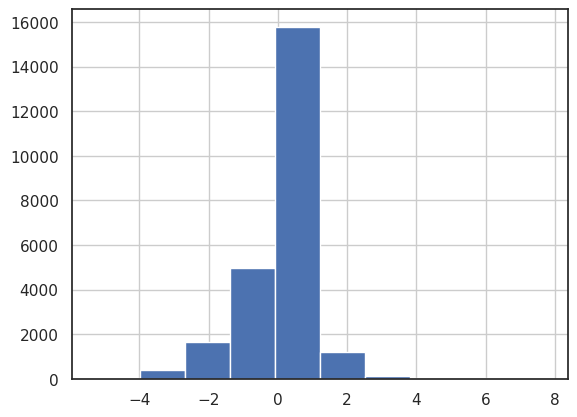

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity'].hist()

##### SCREEN neural progenitor: (n: 1400)
- not open    23121
- open         1113

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized'],
      dtype='object')

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_screen_neural_progenitor'] = element_bcalm_metadata_df_tested_elements_bcalm.apply(plotting_open_regions_screen_ENCFF221LCO_neural_progenitor, axis=1)
element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_screen_neural_progenitor'].value_counts()

plotting_label_open_screen_neural_progenitor
not open    23121
open         1113
Name: count, dtype: int64

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decoration

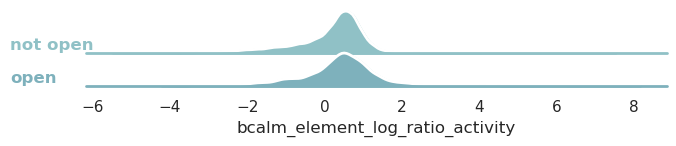

In [ ]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(element_bcalm_metadata_df_tested_elements_bcalm, row="plotting_label_open_screen_neural_progenitor", hue="plotting_label_open_screen_neural_progenitor", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.13, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "bcalm_element_log_ratio_activity")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of open and closed reginos in NGN2 derived WTC11 neurons")

##### NGN2 derived neurons: (n:286)
- not open    23996
- open          238

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_ngn2'] = element_bcalm_metadata_df_tested_elements_bcalm.apply(plotting_open_regions_NGN2_wtc11, axis=1)


In [ ]:
# element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_ngn2'].value_counts(normalize=True)
element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_ngn2'].value_counts()

plotting_label_open_ngn2
not open    23996
open          238
Name: count, dtype: int64

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  

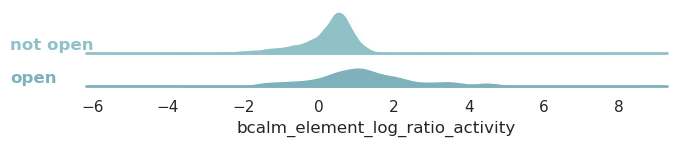

In [ ]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(element_bcalm_metadata_df_tested_elements_bcalm, row="plotting_label_open_ngn2", hue="plotting_label_open_ngn2", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.13, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "bcalm_element_log_ratio_activity")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of open and closed reginos in NGN2 derived WTC11 neurons")

##### H9 neuro progenitor (n:~735)


In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,element_vs_negative_control_adj_pValue,region_id,open_screen_ENCFF221LCO_neural_progenitor,open_NGN2_wtc11_atac,open_H9_neural_progenitor,open_E2G_neural_progenitor_H9,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,1.000000e+00,chr1:2181843-2182113,False,False,False,False,-1.898809,-0.924899,not open,not open
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,6.968128e-11,chr1:2182439-2182709,False,False,False,False,1.102990,0.233557,not open,not open
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,1.400712e-04,chr1:2188389-2188659,False,False,False,False,-0.029607,-0.203536,not open,not open
5,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,3.601548e-08,chr1:2192636-2192906,False,False,False,False,0.379973,-0.045471,not open,not open
7,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,1.000000e+00,chr1:2203380-2203650,False,False,False,False,-2.386399,-1.113070,not open,not open
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27559,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,1.700692e-03,chrX:154519466-154519736,False,False,False,False,-0.283274,-0.301431,not open,not open
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,1.392508e-23,chrX:154539055-154539325,False,False,False,False,1.230108,0.282614,not open,not open
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,2.782262e-13,chrX:154545000-154545270,False,False,False,False,1.892138,0.538105,not open,not open
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,1.000000e+00,chrX:154549802-154550072,False,False,False,False,-2.094885,-1.000569,not open,not open


In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_screen_H9_neural_progenitor'] = element_bcalm_metadata_df_tested_elements_bcalm.apply(plotting_open_regions_screen_H9_neural_progenitor, axis=1)
# element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_screen_H9_neural_progenitor'].value_counts(normalize=True)
element_bcalm_metadata_df_tested_elements_bcalm['plotting_label_open_screen_H9_neural_progenitor'].value_counts()

plotting_label_open_screen_H9_neural_progenitor
not open    23622
open          612
Name: count, dtype: int64

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  

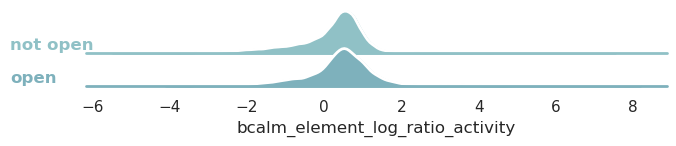

In [ ]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(element_bcalm_metadata_df_tested_elements_bcalm, row="plotting_label_open_screen_H9_neural_progenitor", hue="plotting_label_open_screen_H9_neural_progenitor", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.13, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "bcalm_element_log_ratio_activity")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)


##### E2G neural progenitor (H9): (n: 1113)
- not open    23121
- open         1113

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm['plotting_open_regions_E2G_H9_neural_progenitor'] = element_bcalm_metadata_df_tested_elements_bcalm.apply(plotting_open_regions_E2G_H9_neural_progenitor, axis=1)
element_bcalm_metadata_df_tested_elements_bcalm['plotting_open_regions_E2G_H9_neural_progenitor'].value_counts()

plotting_open_regions_E2G_H9_neural_progenitor
not E2G    23517
E2G          717
Name: count, dtype: int64

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  

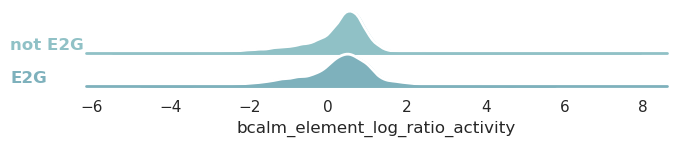

In [ ]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(element_bcalm_metadata_df_tested_elements_bcalm, row="plotting_open_regions_E2G_H9_neural_progenitor", hue="plotting_open_regions_E2G_H9_neural_progenitor", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.13, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "bcalm_element_log_ratio_activity")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)


#### Check for significant difference between open WTC11 ngn2 derived neurons

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, permutation_test

print("Statistical difference between open chromatin activity NGN2 and the other group")

# Example: Assume element_bcalm_metadata_df_tested_elements has a boolean column 'group_A' and a numerical column 'bcalm_element_log_ratio_activity'
open_ngn2 = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_NGN2_wtc11_atac'] == True]['bcalm_element_log_ratio_activity']
not_open_ngn2_overlap = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_NGN2_wtc11_atac'] == False]['bcalm_element_log_ratio_activity']

print("open: set size: ", open_ngn2.shape[0])
print("Not open: set size: ", not_open_ngn2_overlap.shape[0])


def bootstrap_ci(data1, data2, n_boot=10000):
    boot_diffs = []
    for _ in range(n_boot):
        boot1 = np.random.choice(data1, size=len(data1), replace=True)
        boot2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    return np.percentile(boot_diffs, [2.5, 97.5])


ci = bootstrap_ci(open_ngn2, not_open_ngn2_overlap)
print(f"Bootstrap 95% CI: {ci}")

# # Mann–Whitney U Test
# u_stat, mw_p_value = mannwhitneyu(open_ngn2, not_open_ngn2_overlap, alternative='greater')
# print(f"Mann-Whitney U test statistic: {u_stat}, p-value: {mw_p_value}")

# # Define a statistic function that computes the difference in medians.
# # You can also use the mean if preferred.
# def median_diff(x, y):
#     return np.median(x) - np.median(y)

# # Permutation Test using SciPy's permutation_test
# perm_result = permutation_test(
#     data=(open_ngn2, not_open_ngn2_overlap),
#     statistic=median_diff,
#     permutation_type='independent',
#     alternative='greater',
#     n_resamples=1000  # number of permutations
# )

# print("Permutation test statistic:", perm_result.statistic)
# print("Permutation test p-value:", perm_result.pvalue)


Statistical difference between open chromatin activity NGN2 and the other group
open: set size:  238
Not open: set size:  23996


Bootstrap 95% CI: [0.91824895 1.33510611]


#### Check for significant difference between neural progenitor sequences vs not open in neural progenitor sequences

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, permutation_test

print("Statistical difference between open chromatin activity SCREEN neural progenitor and not")

# Example: Assume element_bcalm_metadata_df_tested_elements has a boolean column 'group_A' and a numerical column 'bcalm_element_log_ratio_activity'
open_neuroal_progenitor = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_screen_ENCFF221LCO_neural_progenitor'] == True]['bcalm_element_log_ratio_activity']
not_open_neuroal_progenitor_overlap = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_screen_ENCFF221LCO_neural_progenitor'] == False]['bcalm_element_log_ratio_activity']

print("open: set size: ", open_neuroal_progenitor.shape[0])
print("Not open: set size: ", not_open_neuroal_progenitor_overlap.shape[0])


def bootstrap_ci(data1, data2, n_boot=10000):
    boot_diffs = []
    for _ in range(n_boot):
        boot1 = np.random.choice(data1, size=len(data1), replace=True)
        boot2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    return np.percentile(boot_diffs, [2.5, 97.5])


ci = bootstrap_ci(open_neuroal_progenitor, not_open_neuroal_progenitor_overlap)
print(f"Bootstrap 95% CI: {ci}")

# # Mann–Whitney U Test
# u_stat, mw_p_value = mannwhitneyu(open_neuroal_progenitor, not_open_neuroal_progenitor_overlap, alternative='greater')
# print(f"Mann-Whitney U test statistic: {u_stat}, p-value: {mw_p_value}")

# # Define a statistic function that computes the difference in medians.
# # You can also use the mean if preferred.
# def median_diff(x, y):
#     return np.median(x) - np.median(y)

# # Permutation Test using SciPy's permutation_test
# perm_result = permutation_test(
#     data=(open_neuroal_progenitor, not_open_neuroal_progenitor_overlap),
#     statistic=median_diff,
#     permutation_type='independent',
#     alternative='greater',
#     n_resamples=1000  # number of permutations
# )

# print("Permutation test statistic:", perm_result.statistic)
# print("Permutation test p-value:", perm_result.pvalue)

Statistical difference between open chromatin activity SCREEN neural progenitor and not
open: set size:  1113
Not open: set size:  23121
Bootstrap 95% CI: [0.2147872 0.3577858]


#### Check for significant difference between H9 neural progenitor sequences vs not open in neural progenitor sequences

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, permutation_test

print("Statistical difference between open chromatin activity NGN2 and the other group")

# Example: Assume element_bcalm_metadata_df_tested_elements has a boolean column 'group_A' and a numerical column 'bcalm_element_log_ratio_activity'
open_H9_neuroal_progenitor = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor'] == True]['bcalm_element_log_ratio_activity']
not_open_H9_neuroal_progenitor_overlap = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor'] == False]['bcalm_element_log_ratio_activity']

print("open: set size: ", open_H9_neuroal_progenitor.shape[0])
print("Not open: set size: ", not_open_H9_neuroal_progenitor_overlap.shape[0])


def bootstrap_ci(data1, data2, n_boot=10000):
    boot_diffs = []
    for _ in range(n_boot):
        boot1 = np.random.choice(data1, size=len(data1), replace=True)
        boot2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    return np.percentile(boot_diffs, [2.5, 97.5])


ci = bootstrap_ci(open_H9_neuroal_progenitor, not_open_H9_neuroal_progenitor_overlap)
print(f"Bootstrap 95% CI: {ci}")


# # Mann–Whitney U Test
# u_stat, mw_p_value = mannwhitneyu(open_ngn2, not_open_ngn2_overlap, alternative='greater')
# print(f"Mann-Whitney U test statistic: {u_stat}, p-value: {mw_p_value}")

# # Define a statistic function that computes the difference in medians.
# # You can also use the mean if preferred.
# def median_diff(x, y):
#     return np.median(x) - np.median(y)

# # Permutation Test using SciPy's permutation_test
# perm_result = permutation_test(
#     data=(open_ngn2, not_open_ngn2_overlap),
#     statistic=median_diff,
#     permutation_type='independent',
#     alternative='greater',
#     n_resamples=1000  # number of permutations
# )

# print("Permutation test statistic:", perm_result.statistic)
# print("Permutation test p-value:", perm_result.pvalue)

# from scipy.stats import brunnermunzel

# stat, p = brunnermunzel(open_H9_neuroal_progenitor, not_open_H9_neuroal_progenitor_overlap)
# print(f"Brunner-Munzel test: p-value = {p}")



Statistical difference between open chromatin activity NGN2 and the other group
open: set size:  612
Not open: set size:  23622
Bootstrap 95% CI: [0.17182559 0.34734674]


#### Check for significant difference between E2G H9 neural progenitor sequences vs not open in neural progenitor sequences

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor'],
      dtype='object')

In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, permutation_test

print("Statistical difference between open chromatin activity NGN2 and the other group")

# Example: Assume element_bcalm_metadata_df_tested_elements has a boolean column 'group_A' and a numerical column 'bcalm_element_log_ratio_activity'
open_H9_neuroal_progenitor = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9'] == True]['bcalm_element_log_ratio_activity']
not_open_H9_neuroal_progenitor_overlap = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9'] == False]['bcalm_element_log_ratio_activity']

print("open: set size: ", open_H9_neuroal_progenitor.shape[0])
print("Not open: set size: ", not_open_H9_neuroal_progenitor_overlap.shape[0])


def bootstrap_ci(data1, data2, n_boot=10000):
    boot_diffs = []
    for _ in range(n_boot):
        boot1 = np.random.choice(data1, size=len(data1), replace=True)
        boot2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    return np.percentile(boot_diffs, [2.5, 97.5])


ci = bootstrap_ci(open_H9_neuroal_progenitor, not_open_H9_neuroal_progenitor_overlap)
print(f"Bootstrap 95% CI: {ci}")

Statistical difference between open chromatin activity NGN2 and the other group
open: set size:  717
Not open: set size:  23517
Bootstrap 95% CI: [0.02062743 0.18781613]


In [ ]:
# difference between e2g and open in neural progenitor

In [ ]:
E2G_H9_neuroal_progenitor_overlap = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9'] == True]['bcalm_element_log_ratio_activity']
H9_neuroal_progenitor_overlap = element_bcalm_metadata_df_tested_elements_bcalm[element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor'] == True]['bcalm_element_log_ratio_activity']


print("open: set size: ", open_H9_neuroal_progenitor.shape[0])
print("Not open: set size: ", not_open_H9_neuroal_progenitor_overlap.shape[0])


def bootstrap_ci(data1, data2, n_boot=10000):
    boot_diffs = []
    for _ in range(n_boot):
        boot1 = np.random.choice(data1, size=len(data1), replace=True)
        boot2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(boot1) - np.mean(boot2))
    return np.percentile(boot_diffs, [2.5, 97.5])


ci = bootstrap_ci(open_H9_neuroal_progenitor, not_open_H9_neuroal_progenitor_overlap)
print(f"Bootstrap 95% CI: {ci}")

open: set size:  717
Not open: set size:  23517
Bootstrap 95% CI: [0.01983429 0.18758622]


In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor'],
      dtype='object')

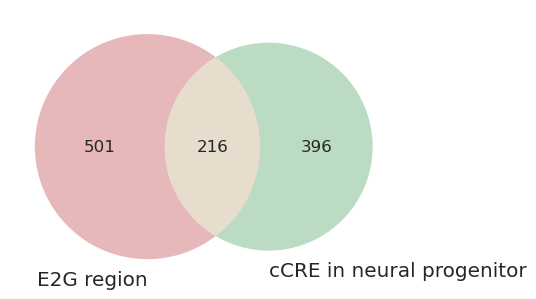

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


# Compute set sizes
open_open_H9_neuroal_progenitor = ((element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9']) & (~element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor'])).sum()
only_screen_neural_progenitor = ((element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor']) & (~element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9'])).sum()
open_both = ((element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9']) & (element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor'])).sum()
closed_both = ((~element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9']) & (~element_bcalm_metadata_df_tested_elements_bcalm['open_H9_neural_progenitor'])).sum()  # Rows in neither A nor B
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn2(subsets=(open_open_H9_neuroal_progenitor, only_screen_neural_progenitor, open_both), set_labels=('E2G region', 'cCRE in neural progenitor'))
plt.show()


### Active elements according to the data
- active: more than scrambled
- active: more than negative control

Number of active elements:  547


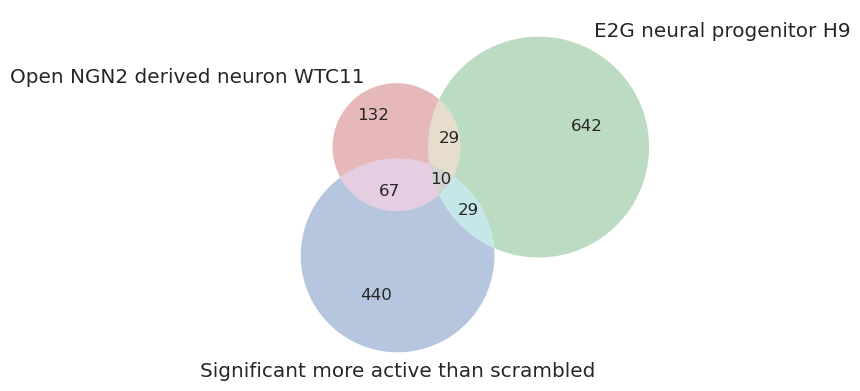

In [ ]:
# active_elements_vs_scrambled = element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm["bcalm_element_adjusted_p_value"] < 0.05].copy()
# active_elements_vs_scrambled
# more_active_elements_vs_scrambled = active_elements_vs_scrambled.loc[active_elements_vs_scrambled['bcalm_element_log_ratio_activity'] > 0].copy()
element_bcalm_metadata_df_tested_elements_bcalm["more_active_scrambled"] = (element_bcalm_metadata_df_tested_elements_bcalm["bcalm_element_adjusted_p_value"] < 0.05) & (element_bcalm_metadata_df_tested_elements_bcalm['bcalm_element_log_ratio_activity'] > 0)
print("Number of active elements: ", element_bcalm_metadata_df_tested_elements_bcalm["more_active_scrambled"].sum())
# what is the overlap to open chromatin data?
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

set_of_open_chromatin_atac_regions = set(element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm['open_NGN2_wtc11_atac']]['region_id'].to_list())
set_of_e2g_region_neural_progenitors = set(element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9']]['region_id'].to_list())
set_of_active_elements = set(element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm['more_active_scrambled']]['region_id'].to_list())

venn3([set_of_open_chromatin_atac_regions, set_of_e2g_region_neural_progenitors, set_of_active_elements], ('Open NGN2 derived neuron WTC11', 'E2G neural progenitor H9', 'Significant more active than scrambled'))


In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled'],
      dtype='object')

Number of active elements:  20113


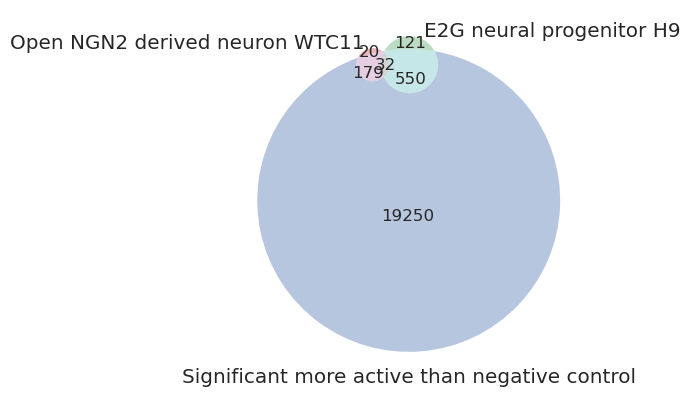

In [ ]:
# active_elements_vs_scrambled = element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm["bcalm_element_adjusted_p_value"] < 0.05].copy()
# active_elements_vs_scrambled
# more_active_elements_vs_scrambled = active_elements_vs_scrambled.loc[active_elements_vs_scrambled['bcalm_element_log_ratio_activity'] > 0].copy()

element_bcalm_metadata_df_tested_elements_bcalm["more_active_negative_ctrl"] = element_bcalm_metadata_df_tested_elements_bcalm["element_vs_negative_control_adj_pValue"] < 0.05
print("Number of active elements: ", element_bcalm_metadata_df_tested_elements_bcalm["more_active_negative_ctrl"].sum())
# what is the overlap to open chromatin data?
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

set_of_open_chromatin_atac_regions = set(element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm['open_NGN2_wtc11_atac']]['region_id'].to_list())
set_of_e2g_region_neural_progenitors = set(element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm['open_E2G_neural_progenitor_H9']]['region_id'].to_list())
set_of_active_elements = set(element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm['more_active_negative_ctrl']]['region_id'].to_list())

venn3([set_of_open_chromatin_atac_regions, set_of_e2g_region_neural_progenitors, set_of_active_elements], ('Open NGN2 derived neuron WTC11', 'E2G neural progenitor H9', 'Significant more active than negative control'))


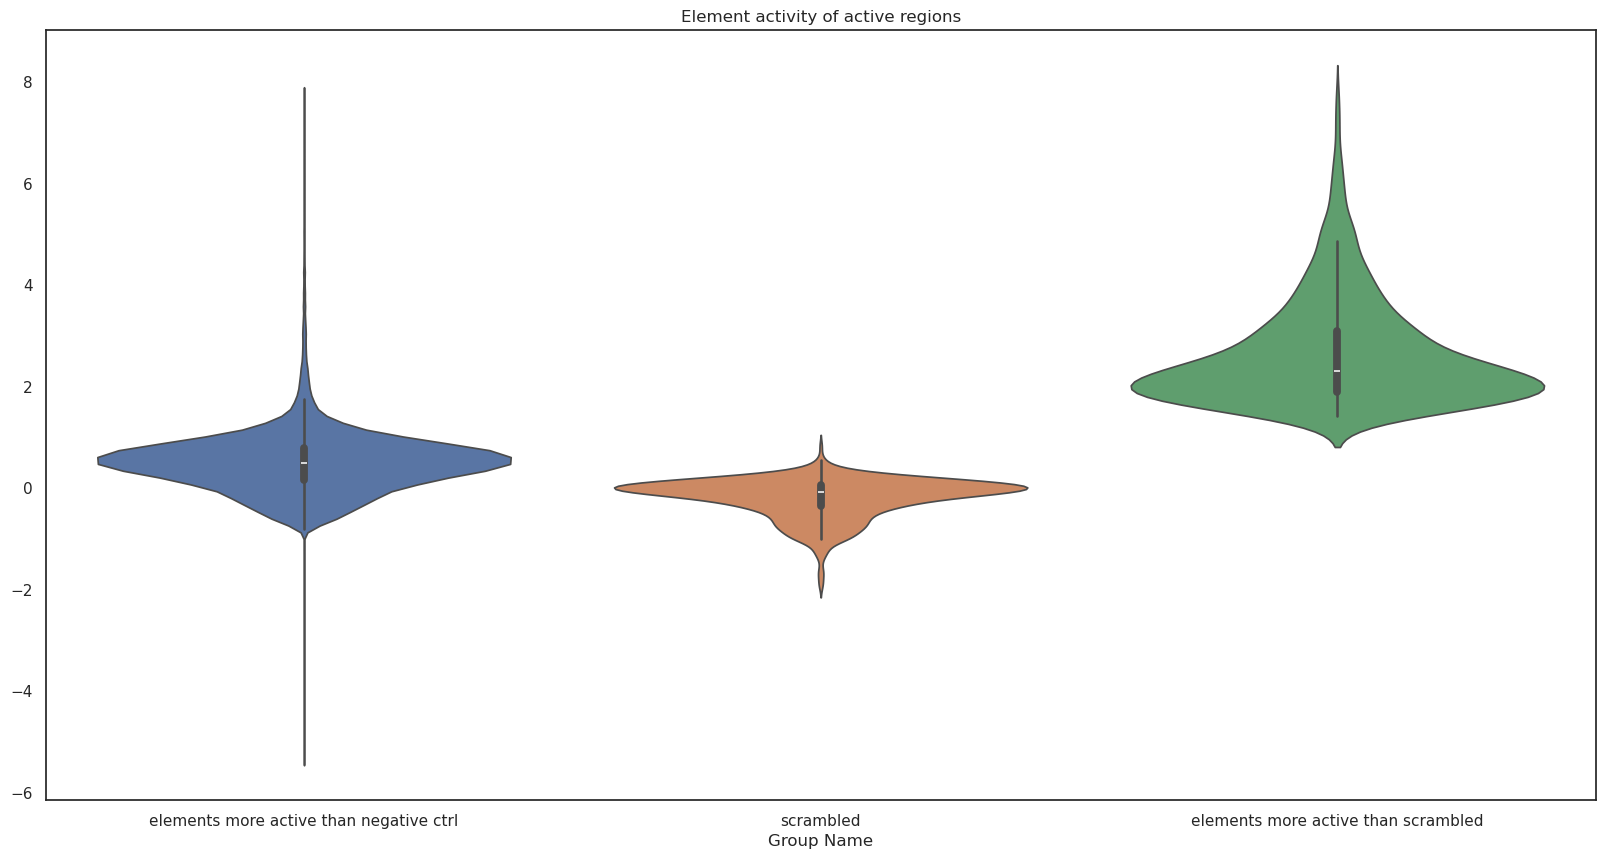

In [ ]:
# violin plot: active elements vs scrambled
import seaborn as sns
import matplotlib.pyplot as plt

# Define a color palette
palette = sns.color_palette("pastel")  # Choose a different palette

columns_of_interest =["Group Name", "bcalm_element_log_ratio_activity", "name"]

# get the active regions:
more_active_scrabled_element_data = element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm["more_active_scrambled"]].copy()
more_active_scrabled_element_data["Group Name"] = "elements more active than scrambled"

# get the neg ctrl active regions:

more_active_neg_ctrl_element_data = element_bcalm_metadata_df_tested_elements_bcalm.loc[element_bcalm_metadata_df_tested_elements_bcalm["more_active_negative_ctrl"]].copy()
more_active_neg_ctrl_element_data["Group Name"] = "elements more active than negative ctrl"
# get the scrambled sequences and combine them to one dataframe
negative_scrambled_sequences = element_bcalm_metadata_df.loc[element_bcalm_metadata_df['label'].isin(["negative_scrambled"])].copy()
negative_scrambled_sequences_bcalm = negative_scrambled_sequences.loc[negative_scrambled_sequences["bcalm_data_exists"]].copy()

negative_scrambled_sequences_bcalm["Group Name"] = "scrambled" # 475



plotting_data = pd.concat([more_active_neg_ctrl_element_data[columns_of_interest], negative_scrambled_sequences_bcalm[columns_of_interest], more_active_scrabled_element_data[columns_of_interest]], ignore_index=True)


# # element_bcalm_metadata_df_tested_elements_bcalm
plt.figure(figsize=(20, 10))
ax = sns.violinplot(x="Group Name", y="bcalm_element_log_ratio_activity", hue="Group Name", data=plotting_data)
plt.title(f"Element activity of active regions")
plt.ylabel("")
plt.show()

### venn diagramm of overlap between open chromatin regions:


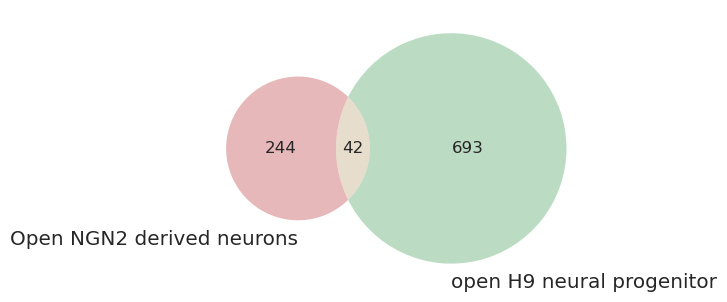

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


# Compute set sizes
open_wtc11_ngn2_atac = ((element_bcalm_metadata_df_tested_elements['open_NGN2_wtc11_atac']) & (~element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor'])).sum()
only_screen_neural_progenitor = ((element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor']) & (~element_bcalm_metadata_df_tested_elements['open_NGN2_wtc11_atac'])).sum()
open_both = ((element_bcalm_metadata_df_tested_elements['open_NGN2_wtc11_atac']) & (element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor'])).sum()
closed_both = ((~element_bcalm_metadata_df_tested_elements['open_NGN2_wtc11_atac']) & (~element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor'])).sum()  # Rows in neither A nor B
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn2(subsets=(open_wtc11_ngn2_atac, only_screen_neural_progenitor, open_both), set_labels=('Open NGN2 derived neurons', 'open H9 neural progenitor'))
plt.show()


Between H9 screen neural progenitor and other neural progenitor

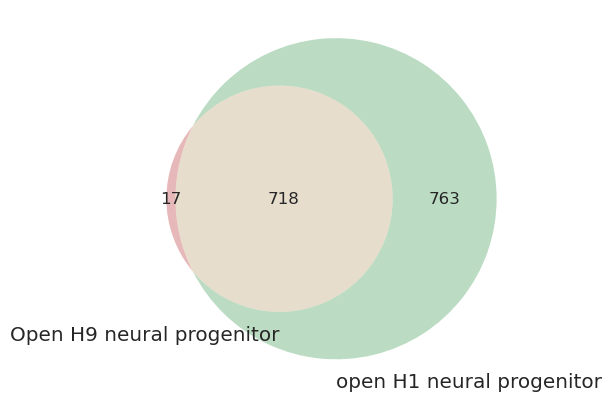

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2


# Compute set sizes
open_wtc11_ngn2_atac = ((element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor']) & (~element_bcalm_metadata_df_tested_elements['open_screen_ENCFF221LCO_neural_progenitor'])).sum()
only_screen_neural_progenitor = ((element_bcalm_metadata_df_tested_elements['open_screen_ENCFF221LCO_neural_progenitor']) & (~element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor'])).sum()
open_both = ((element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor']) & (element_bcalm_metadata_df_tested_elements['open_screen_ENCFF221LCO_neural_progenitor'])).sum()
closed_both = ((~element_bcalm_metadata_df_tested_elements['open_H9_neural_progenitor']) & (~element_bcalm_metadata_df_tested_elements['open_screen_ENCFF221LCO_neural_progenitor'])).sum()  # Rows in neither A nor B
# Plot Venn diagram
plt.figure(figsize=(5, 5))
venn2(subsets=(open_wtc11_ngn2_atac, only_screen_neural_progenitor, open_both), set_labels=('Open H9 neural progenitor', 'open H1 neural progenitor'))
plt.show()

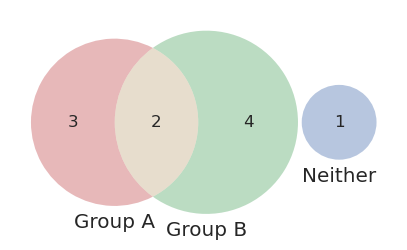

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Example DataFrame
data = {
    'Group_A': [True, False, True, True, False, False, True, False, True, False],
    'Group_B': [False, True, True, False, True, True, False, True, True, False]
}
df = pd.DataFrame(data)

# Define "Neither" as a new group
df['Neither'] = ~(df['Group_A'] | df['Group_B'])  # True where both A and B are False

# Compute set sizes
only_A = ((df['Group_A']) & (~df['Group_B']) & (~df['Neither'])).sum()
only_B = ((df['Group_B']) & (~df['Group_A']) & (~df['Neither'])).sum()
only_neither = df['Neither'].sum()

both_AB = ((df['Group_A']) & (df['Group_B'])).sum()

# The following intersections are logically 0
both_A_Neither = 0
both_B_Neither = 0
all_three = 0  # A, B, and Neither can't be True at the same time

# Plot 3-set Venn diagram
plt.figure(figsize=(5, 5))
venn3(
    subsets=(only_A, only_B, both_AB, only_neither, both_A_Neither, both_B_Neither, all_three),
    set_labels=('Group A', 'Group B', 'Neither')
)

plt.show()


In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled'],
      dtype='object')

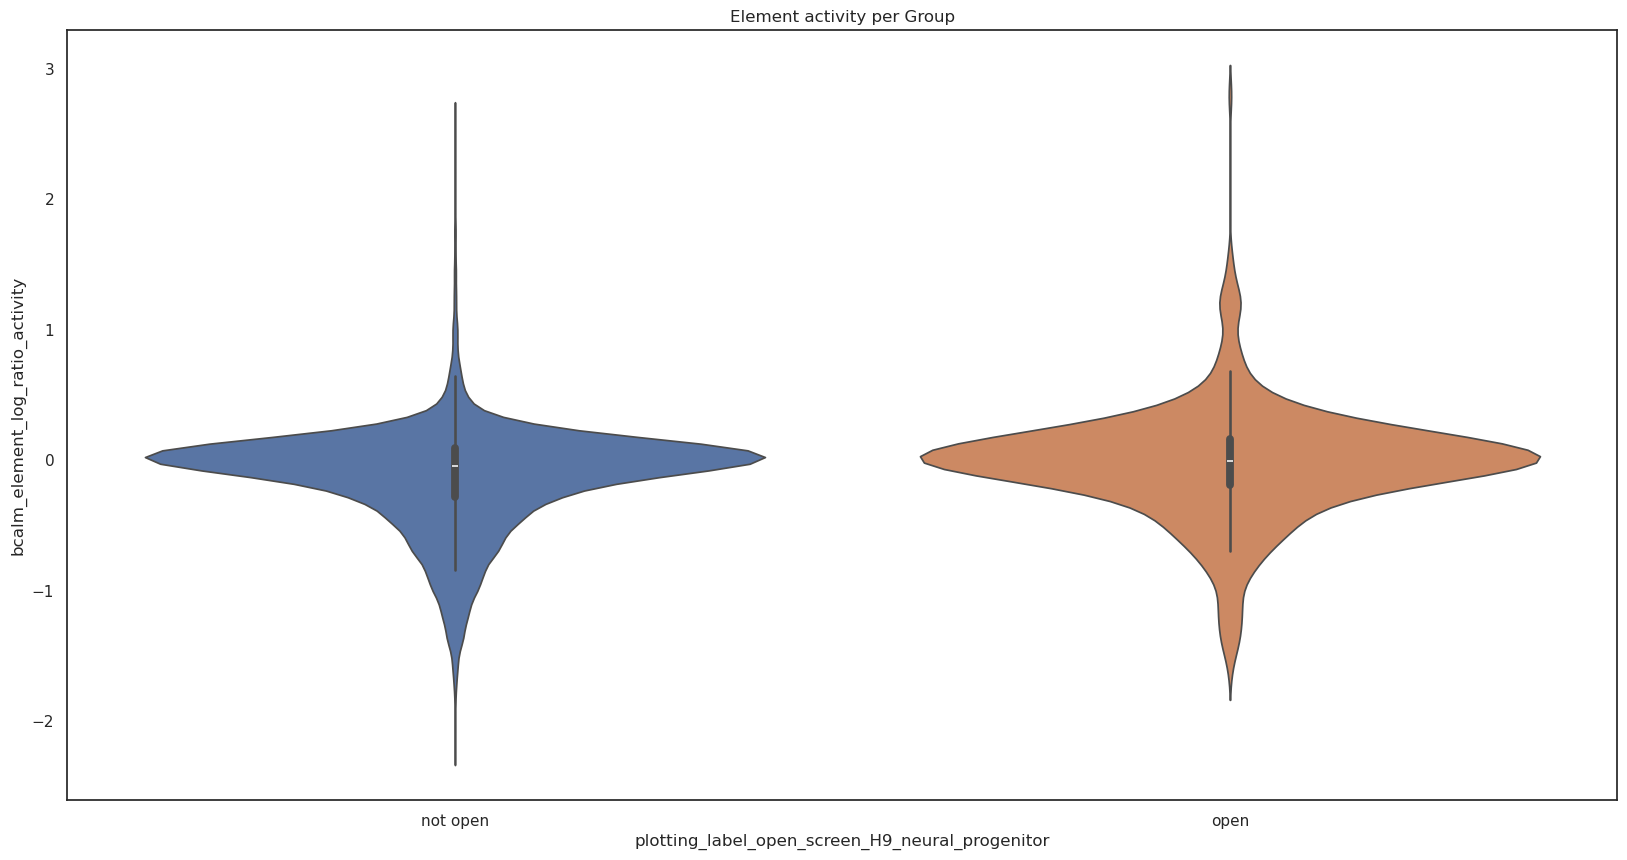

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a color palette
palette = sns.color_palette("pastel")  # Choose a different palette

plt.figure(figsize=(20, 10))
# ax = sns.violinplot(x="label", y="barcodes", hue="label", data=bwa_association_filtered_counts_label)
ax = sns.violinplot(x="plotting_label_open_screen_H9_neural_progenitor", y="bcalm_element_log_ratio_activity", hue="plotting_label_open_screen_H9_neural_progenitor", data=element_bcalm_metadata_df_tested_elements_bcalm)
plt.title(f"Element activity per Group")

plt.show()

### E2G: 
embryonic male neuronal stem cells encode (H1): `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/full_predictions/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_full_predictions.tsv.gz`
- bedpe: `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz`

- 5 day embryonic female human neural progenitor cell (H9): `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/full_predictions/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_full_predictions.tsv.gz`
- bedpe: `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz`

In [ ]:
# bedtools intersect -f 0.5 -F 0.5 -e -a /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/all_80k_regions.bed -b /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz -wa -wb > /home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_E2G_h9_neural_progenitor_cells.bed
e2g_data_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_E2G_h9_neural_progenitor_cells.bed"
e2g_data = pd.read_csv(e2g_data_path, sep="\t")

open_prefix = "E2G_neural_progenitor_H9"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_E2G_h9_neural_progenitor_cells.bed"
open_in_progenitor = pd.read_csv(open_input_data, sep="\t", header=None, names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'] + [num for num in range(10)])
open_in_progenitor
print("Number of open regions: ", open_in_progenitor[f'tmp_open_{open_prefix}_id'].nunique())

open_in_id_list = open_in_progenitor[f'tmp_open_{open_prefix}_id'].to_list()

element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'] = element_bcalm_metadata_df_tested_elements['region_id'].isin(open_in_id_list)
element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'].value_counts()

Number of open regions:  1032


open_E2G_neural_progenitor_H9
False    26427
True      1055
Name: count, dtype: int64

### Enformer

In [ ]:
enformer_dnase_max_element_pred_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/element_enformer_prediction/sequences_enformer_DNase_max.tsv.gz"
enformer_dnase_max_element_pred = pd.read_csv(enformer_dnase_max_element_pred_path, sep="\t")

In [ ]:
enformer_dnase_max_element_pred

,id,DNase_max,max_col
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1717,DNASE:BE2C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.4162,DNASE:spleen male adult (54 years)
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2817,DNASE:RPMI-7951
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1004,DNASE:BE2C
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.9793,DNASE:RPMI-7951
...,...,...,...
80210,MK:tile_2240|chr1-116244322+116244591|scramble...,0.1643,DNASE:SK-MEL-5.1
80211,MK:tile_6675|chr11-2374617+2374886|scramble_ne...,1.0757,DNASE:foreskin melanocyte male newborn
80212,MK:tile_18415|chr17-71181691+71181960|scramble...,0.1672,DNASE:SK-MEL-5
80213,MK:tile_14356|chr15-67031618+67031887|scramble...,0.4432,DNASE:BE2C


In [ ]:
element_bcalm_metadata_df_tested_elements_bcalm

,name,sequence,category,class,source,ref,chr,start,end,strand,...,open_H9_neural_progenitor,open_E2G_neural_progenitor_H9,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,False,False,-1.898809,-0.924899,not open,not open,not open,not E2G,False,False
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,False,False,1.102990,0.233557,not open,not open,not open,not E2G,False,True
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,False,False,-0.029607,-0.203536,not open,not open,not open,not E2G,False,True
5,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AGGGTCTTACTCTGTCACCCAGGCTGGAGTGCAGTGGTGCAATCAT...,element,test,NaN,GRCh38,chr1,2192636,2192906,+,...,False,False,0.379973,-0.045471,not open,not open,not open,not E2G,False,True
7,cardiac_neuro_cava_random:SKI|ENSG00000157933....,GGCTGCCCTGCCCAGGCCTGGGCACAGCTGCACTGACTGTTCCTGG...,element,test,NaN,GRCh38,chr1,2203380,2203650,+,...,False,False,-2.386399,-1.113070,not open,not open,not open,not E2G,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27559,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,CACTATGCCCACCTTAGCTGCCCTTTCTTGGACGATCAGGCCCAGA...,variant,test,NaN,GRCh38,chrX,154519466,154519736,-,...,False,False,-0.283274,-0.301431,not open,not open,not open,not E2G,False,True
27562,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,TTGCTGAGTAGTATCCGTTGTATGAATGCACAGTTTGCCGGGTCAC...,variant,test,NaN,GRCh38,chrX,154539055,154539325,-,...,False,False,1.230108,0.282614,not open,not open,not open,not E2G,False,True
27563,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,False,False,1.892138,0.538105,not open,not open,not open,not E2G,False,True
27564,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,False,False,-2.094885,-1.000569,not open,not open,not open,not E2G,False,False


In [ ]:
if element_bcalm_metadata_df_tested_elements_bcalm.merge(enformer_dnase_max_element_pred, left_on=col_name, right_on="id", how="inner").drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0] != element_bcalm_metadata_df_tested_elements_bcalm.drop_duplicates(subset=[col_chr, col_start, col_end]).shape[0]:
    raise ValueError("Unexpected number of row matchedable")

element_bcalm_enformer_matched = element_bcalm_metadata_df_tested_elements_bcalm.merge(enformer_dnase_max_element_pred, left_on=col_name, right_on="id", how="inner")
# remove enformer id
element_bcalm_enformer_matched = element_bcalm_enformer_matched.drop(columns=["id"])

In [ ]:
element_bcalm_enformer_matched.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'element_vs_negative_control_activity_logFC',
       'element_vs_negative_control_adj_pValue', 'region_id',
       'open_screen_ENCFF221LCO_neural_progenitor', 'open_NGN2_wtc11_atac',
       'open_H9_neural_progenitor', 'open_E2G_neural_progenitor_H9',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized',
       'plotting_label_open_screen_neural_progenitor',
       'plotting_label_open_ngn2',
       'plotting_label_open_screen_H9_neural_progenitor',
       'plotting_open_regions_E2G_H9_neural_progenitor',
       'more_active_scrambled', 'more_active_negative_ctrl', 'DNase_max',
       'max_col'],
      dtype='object')

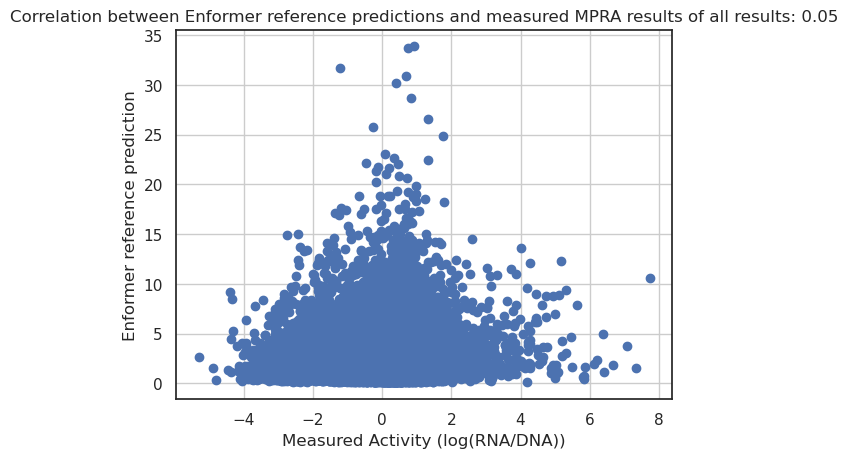

In [ ]:
# Calculate the correlation between enformer predictions and normalized activity
correlation = element_bcalm_enformer_matched[["bcalm_element_log_ratio_activity", "DNase_max"]].corr(method="spearman").iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(element_bcalm_enformer_matched["bcalm_element_log_ratio_activity"], element_bcalm_enformer_matched["DNase_max"])
plt.xlabel('Measured Activity (log(RNA/DNA))')
plt.ylabel('Enformer reference prediction')
plt.title(f'Correlation between Enformer reference predictions and measured MPRA results of all results: {correlation:.2f}')
plt.grid(True)
plt.show()

In [ ]:
# only positive

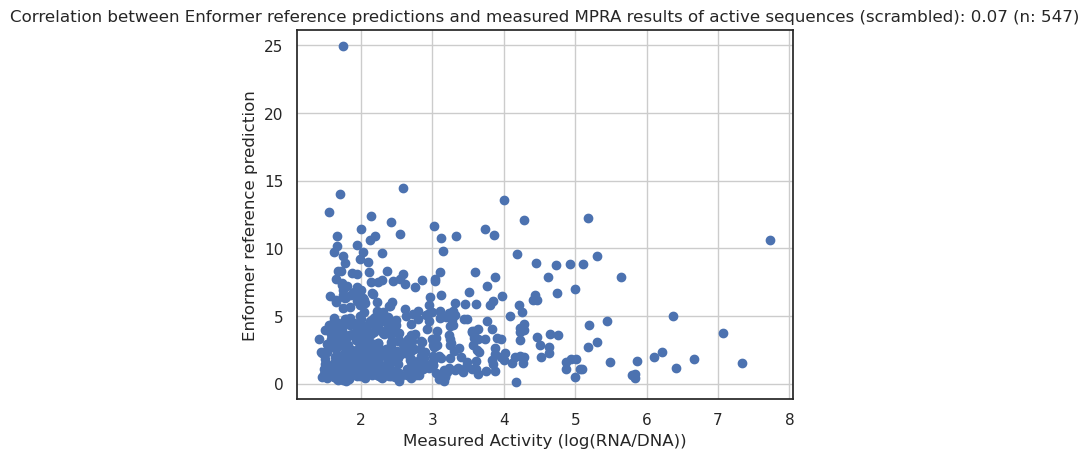

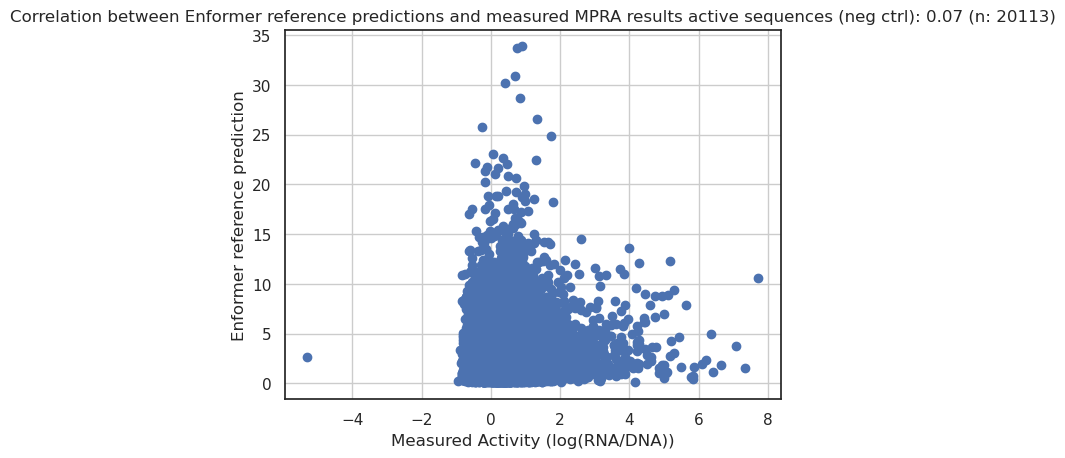

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col
3768,cardiac_neuro_cava_random:NTRK2|ENSG0000014805...,ACTCCATCACATCTCCAATGGGAGTAACACTCCATCTTCTTCGGAA...,element,test,NaN,GRCh38,chr9,84867285,84867555,+,...,-5.293136,-2.23484,not open,not open,not open,not E2G,False,True,2.6269,DNASE:BE2C


In [ ]:

# only active sequences (scrambled):
only_active_scrambled_elements = element_bcalm_enformer_matched.loc[element_bcalm_enformer_matched["more_active_scrambled"]].copy()
# Calculate the correlation between  of '+' strand and '-' strand
correlation = only_active_scrambled_elements[["bcalm_element_log_ratio_activity", "DNase_max"]].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(only_active_scrambled_elements["bcalm_element_log_ratio_activity"], only_active_scrambled_elements["DNase_max"])
plt.xlabel('Measured Activity (log(RNA/DNA))')
plt.ylabel('Enformer reference prediction')
plt.title(f'Correlation between Enformer reference predictions and measured MPRA results of active sequences (scrambled): {correlation:.2f} (n: {only_active_scrambled_elements.shape[0]})')
plt.grid(True)
plt.show()

# only active sequences (negative_control):
only_active_negative_ctrl_elements = element_bcalm_enformer_matched.loc[element_bcalm_enformer_matched["more_active_negative_ctrl"]].copy()
# Calculate the correlation between  of '+' strand and '-' strand
correlation = only_active_negative_ctrl_elements[["bcalm_element_log_ratio_activity", "DNase_max"]].corr().iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(only_active_negative_ctrl_elements["bcalm_element_log_ratio_activity"], only_active_negative_ctrl_elements["DNase_max"])
plt.xlabel('Measured Activity (log(RNA/DNA))')
plt.ylabel('Enformer reference prediction')
plt.title(f'Correlation between Enformer reference predictions and measured MPRA results active sequences (neg ctrl): {correlation:.2f} (n: {only_active_negative_ctrl_elements.shape[0]})')
plt.grid(True)
plt.show()

only_active_negative_ctrl_elements.loc[only_active_negative_ctrl_elements["bcalm_element_log_ratio_activity"] < -2]
# cardiac_neuro_cava_random:NTRK2|ENSG00000148053.18|EH38E2702642_fwd_tile1-1




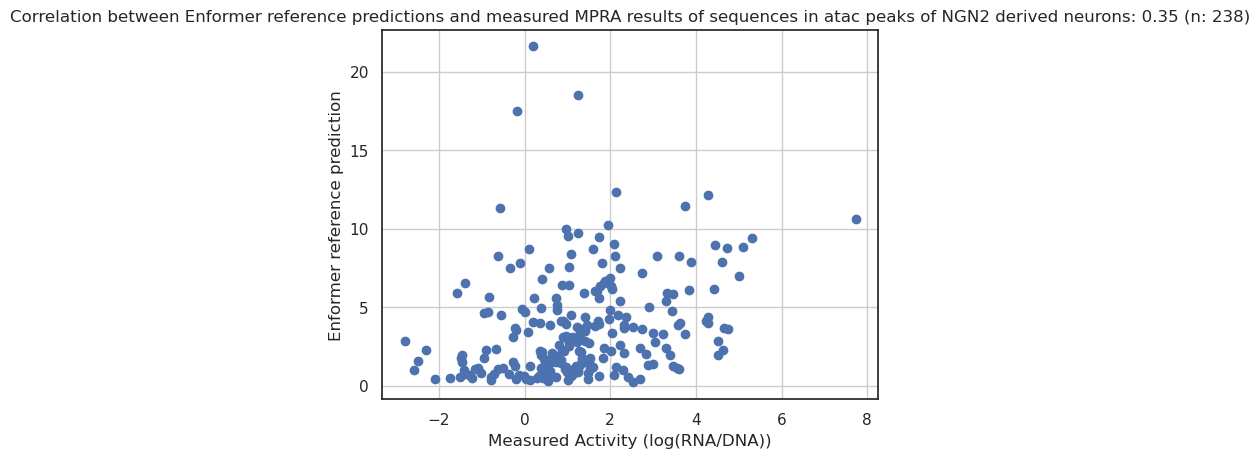

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col
1062,cardiac_neuro_cava_random:NRXN1|ENSG0000017991...,CAGTTCTAGAACACTTTGCCCCAAAGCATTCCAACCAGGGGTTGAA...,element,test,NaN,GRCh38,chr2,50922608,50922878,-,...,-2.298594,-1.079185,not open,open,not open,not E2G,False,False,2.2810,DNASE:BE2C
15460,cardiac_neuro_cava_random:REF_CDH2|ENSG0000017...,TTAGAAAGTGCAACAGTATACGTTAATAATTCAAGCTACAGACATG...,variant,test,NaN,GRCh38,chr18,27993371,27993641,-,...,-2.482426,-1.150129,not open,open,not open,not E2G,False,False,1.5743,DNASE:BE2C
15633,cardiac_neuro_cava_random:REF_CELF4|ENSG000001...,GCCACCAGACAGGCCTGCCAGGGAGGGAGTGATGCTGGAGCACCCA...,variant,test,NaN,GRCh38,chr18,37394638,37394908,-,...,-2.085084,-0.996786,not open,open,not open,not E2G,False,False,0.4361,DNASE:spleen male adult (54 years)
18132,cardiac_neuro_cava_random:REF_TNRC6B|ENSG00000...,ACCCAATGAGAAGTCTTACAACATCAGAAGCTGTCTGCCAATGCGC...,variant,test,NaN,GRCh38,chr22,40010001,40010271,+,...,-2.574563,-1.185686,not open,open,not open,E2G,False,False,0.9741,DNASE:SK-MEL-5.1
18435,cardiac_neuro_cava_random:REF_SATB1|ENSG000001...,TCAAATTGACCATTGCAACACATGGTTTCCCCTGAAACTAGCTGTG...,variant,test,NaN,GRCh38,chr3,18370717,18370987,-,...,-2.799817,-1.272617,not open,open,not open,not E2G,False,False,2.8748,DNASE:BE2C


In [ ]:
# open chromatin correlation
open_ngn2_wtc11_atac_elements = element_bcalm_enformer_matched.loc[element_bcalm_enformer_matched["open_NGN2_wtc11_atac"]].copy()
# Calculate the correlation between  of '+' strand and '-' strand
correlation = open_ngn2_wtc11_atac_elements[["bcalm_element_log_ratio_activity", "DNase_max"]].corr(method="spearman").iloc[0, 1]
correlation = open_ngn2_wtc11_atac_elements[["bcalm_element_log_ratio_activity", "DNase_max"]].corr(method="pearson").iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(open_ngn2_wtc11_atac_elements["bcalm_element_log_ratio_activity"], open_ngn2_wtc11_atac_elements["DNase_max"])
plt.xlabel('Measured Activity (log(RNA/DNA))')
plt.ylabel('Enformer reference prediction')
plt.title(f'Correlation between Enformer reference predictions and measured MPRA results of sequences in atac peaks of NGN2 derived neurons: {correlation:.2f} (n: {open_ngn2_wtc11_atac_elements.shape[0]})')
plt.grid(True)
plt.show()

open_ngn2_wtc11_atac_elements.loc[open_ngn2_wtc11_atac_elements["bcalm_element_log_ratio_activity"] < -2]
# cardiac_neuro_cava_random:NTRK2|ENSG00000148053.18|EH38E2702642_fwd_tile1-1

In [ ]:
plotting_open_regions_E2G_H9_neural_progenitor

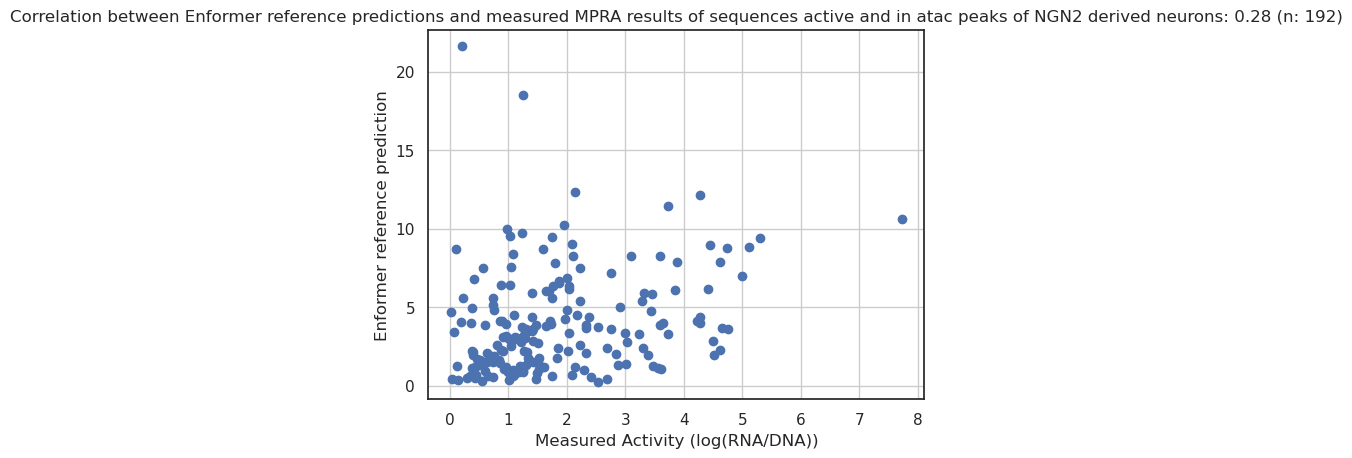

,name,sequence,category,class,source,ref,chr,start,end,strand,...,bcalm_element_log_ratio_activity_z_normalized,bcalm_element_log_ratio_activity_not_normlized,plotting_label_open_screen_neural_progenitor,plotting_label_open_ngn2,plotting_label_open_screen_H9_neural_progenitor,plotting_open_regions_E2G_H9_neural_progenitor,more_active_scrambled,more_active_negative_ctrl,DNase_max,max_col


In [ ]:
# open chromatin correlation
open_ngn2_wtc11_atac_elements_active = element_bcalm_enformer_matched.loc[element_bcalm_enformer_matched["open_NGN2_wtc11_atac"] & (element_bcalm_enformer_matched["bcalm_element_log_ratio_activity"] > 0)].copy()
# Calculate the correlation between  of '+' strand and '-' strand
correlation = open_ngn2_wtc11_atac_elements_active[["bcalm_element_log_ratio_activity", "DNase_max"]].corr(method="spearman").iloc[0, 1]
correlation = open_ngn2_wtc11_atac_elements_active[["bcalm_element_log_ratio_activity", "DNase_max"]].corr(method="pearson").iloc[0, 1]
correlation
# Plot the correlation
plt.scatter(open_ngn2_wtc11_atac_elements_active["bcalm_element_log_ratio_activity"], open_ngn2_wtc11_atac_elements_active["DNase_max"])
plt.xlabel('Measured Activity (log(RNA/DNA))')
plt.ylabel('Enformer reference prediction')
plt.title(f'Correlation between Enformer reference predictions and measured MPRA results of sequences active and in atac peaks of NGN2 derived neurons: {correlation:.2f} (n: {open_ngn2_wtc11_atac_elements_active.shape[0]})')
plt.grid(True)
plt.show()

open_ngn2_wtc11_atac_elements_active.loc[open_ngn2_wtc11_atac_elements_active["bcalm_element_log_ratio_activity"] < -2]
# cardiac_neuro_cava_random:NTRK2|ENSG00000148053.18|EH38E2702642_fwd_tile1-1

In [ ]:
if write_output:
    output_path = config["files"]["creating"]["metadata_enformer_open_normalized_table_032025"]
    element_bcalm_enformer_matched.to_csv(output_path, sep="\t", header=True, index=False)